<a href="https://colab.research.google.com/github/srishtinsaan/Customer-Insights-Dashboard/blob/main/Customer_Insights_%26_Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [38]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [39]:
file_name = "Online Retail.xlsx"

df = pd.read_excel(file_name)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [40]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [41]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [43]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [44]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [45]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [46]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [47]:
print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Unique countries:", df["Country"].nunique())

Unique invoices: 25900
Unique products: 4070
Unique customers: 4372
Unique countries: 38


In [48]:
print("Quantity statistics:")
display(df["Quantity"].describe())

print("\nUnit Price statistics:")
display(df["UnitPrice"].describe())

Quantity statistics:


,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000



Unit Price statistics:


,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


Negative quantity check

In [49]:
negative_quantity = df[df["Quantity"] < 0]

print("Negative quantity rows:", len(negative_quantity))

negative_quantity.head()

Negative quantity rows: 10624


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


Cancelled transactions invoices are there or not

In [50]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

cancelled = df[
    df["InvoiceNo"].str.startswith("C")
]

print("Cancelled transactions:", len(cancelled))

cancelled.head()

Cancelled transactions: 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


price = 0 or less

In [51]:
invalid_price = df[df["UnitPrice"] <= 0]

print("Rows with UnitPrice <= 0:", len(invalid_price))

invalid_price.head()

Rows with UnitPrice <= 0: 2517


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


Basic data-quality report

In [52]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_%": (
        df.isnull().mean().values * 100
    ).round(2),
    "Unique_Values": [
        df[col].nunique()
        for col in df.columns
    ]
})

quality_report

,Column,Data_Type,Missing_Count,Missing_%,Unique_Values
0,InvoiceNo,object,0,0.00,25900
1,StockCode,object,0,0.00,4070
2,Description,object,1454,0.27,4223
3,Quantity,int64,0,0.00,722
4,InvoiceDate,datetime64[ns],0,0.00,23260
5,UnitPrice,float64,0,0.00,1630
6,CustomerID,float64,135080,24.93,4372
7,Country,object,0,0.00,38


EDA

Distribution of Quantity

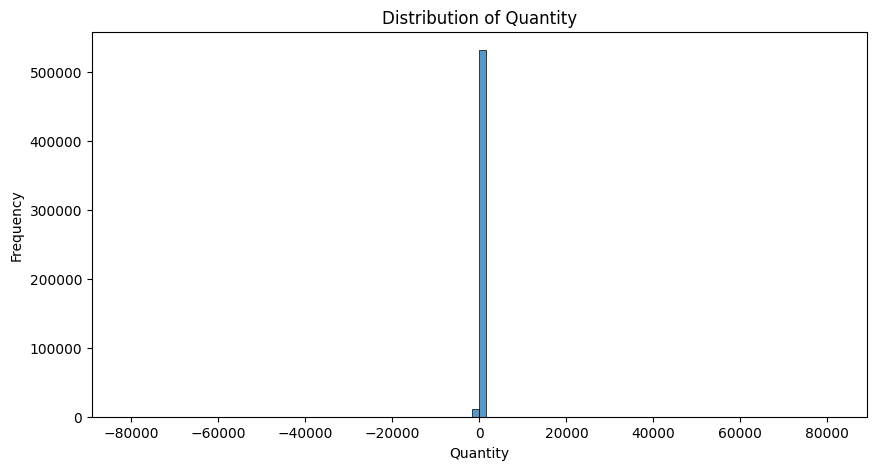

In [53]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Quantity"],
    bins=100
)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

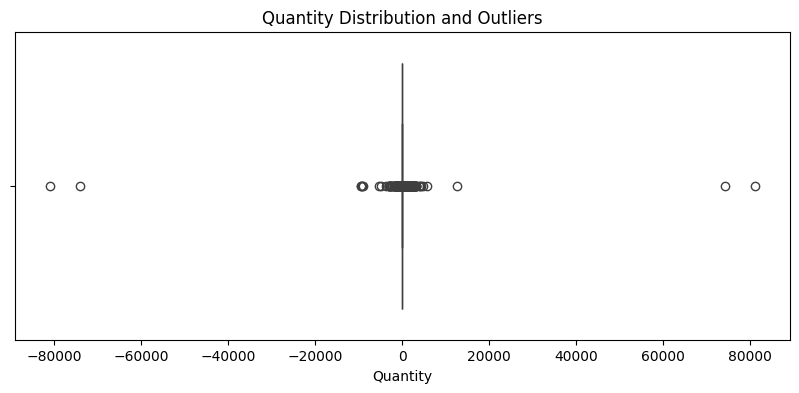

In [54]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["Quantity"]
)

plt.title("Quantity Distribution and Outliers")
plt.xlabel("Quantity")

plt.show()

Unit price distribution

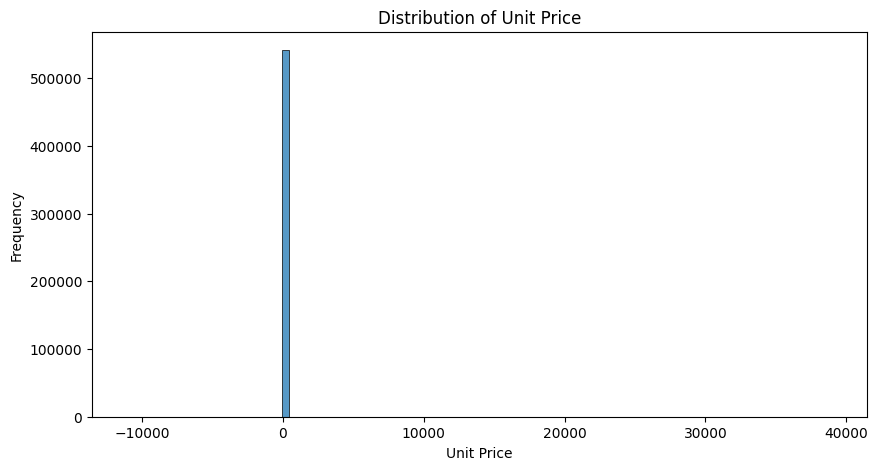

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["UnitPrice"],
    bins=100
)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

In [56]:
df_clean = df.copy()

print(df_clean.shape)

(541909, 8)


Remove exact duplicates


In [57]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 541909
Rows after: 536641
Duplicates removed: 5268


Check missing CustomerID

In [58]:
customer_missing = df_clean["CustomerID"].isna()

print("Missing CustomerID:", customer_missing.sum())
print(
    "Missing CustomerID %:",
    round(customer_missing.mean() * 100, 2),
    "%"
)

Missing CustomerID: 135037
Missing CustomerID %: 25.16 %


Handle cancelled orders

In [59]:
df_clean["Is_Cancelled"] = (
    df_clean["InvoiceNo"].astype(str).str.startswith("C")
)

print(
    "Cancelled transactions:",
    df_clean["Is_Cancelled"].sum()
)

Cancelled transactions: 9251


In [60]:
print(
    "Cancellation percentage:",
    round(
        df_clean["Is_Cancelled"].mean() * 100,
        2
    ),
    "%"
)

Cancellation percentage: 1.72 %


In [61]:
cancelled_df = df_clean[
    df_clean["Is_Cancelled"]
].copy()

print("Cancelled dataset:", cancelled_df.shape)

Cancelled dataset: (9251, 9)


In [62]:
df_clean = df_clean[
    ~df_clean["Is_Cancelled"]
].copy()

print("Remaining rows:", len(df_clean))

Remaining rows: 527390


Handle invalid UnitPrice

In [63]:
invalid_price = df_clean[
    df_clean["UnitPrice"] <= 0
]

print("Invalid UnitPrice rows:", len(invalid_price))

invalid_price.head()

Invalid UnitPrice rows: 2512


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Is_Cancelled
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,False
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,False
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,False
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,False
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,False


For our sales analysis, a zero or negative unit price isn't useful.

Remove them:

In [64]:
df_clean = df_clean[
    df_clean["UnitPrice"] > 0
].copy()

print("Rows after price cleaning:", len(df_clean))

Rows after price cleaning: 524878


In [65]:
before = len(df_clean)

df_clean = df_clean[
    df_clean["CustomerID"].notna()
].copy()

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 524878
Rows after: 392692
Rows removed: 132186


In [66]:
df_clean["CustomerID"] = (
    df_clean["CustomerID"]
    .astype(int)
)

In [67]:
df_clean["CustomerID"].head()

,CustomerID
0,17850
1,17850
2,17850
3,17850
4,17850


Convert InvoiceDate

In [68]:
print(df_clean["InvoiceDate"].dtype)

datetime64[ns]


In [69]:
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

In [70]:
print(df_clean["InvoiceDate"].dtype)

datetime64[ns]


Create Revenue

In [71]:
df_clean["Revenue"] = (
    df_clean["Quantity"] *
    df_clean["UnitPrice"]
)

In [72]:
df_clean[
    [
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].head(10)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


Create date features

In [73]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Day_Name"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

In [74]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [75]:
monthly_revenue = (
    df_clean.groupby(["Year", "Month"])["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,Year,Month,Revenue
0,2010,12,570422.730
1,2011,1,568101.310
2,2011,2,446084.920
3,2011,3,594081.760
4,2011,4,468374.331
5,2011,5,677355.150
6,2011,6,660046.050
7,2011,7,598962.901
8,2011,8,644051.040
9,2011,9,950690.202


In [76]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


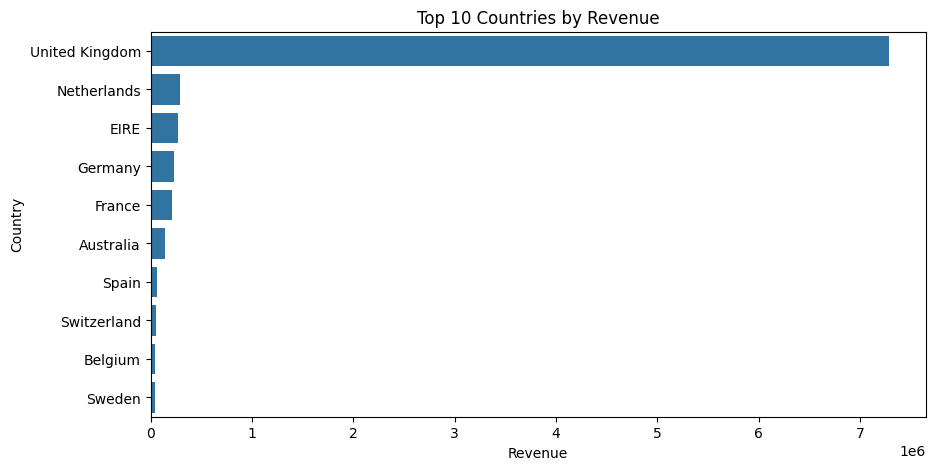

In [77]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=country_revenue.head(10).values,
    y=country_revenue.head(10).index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

Top Products

In [78]:
product_revenue = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


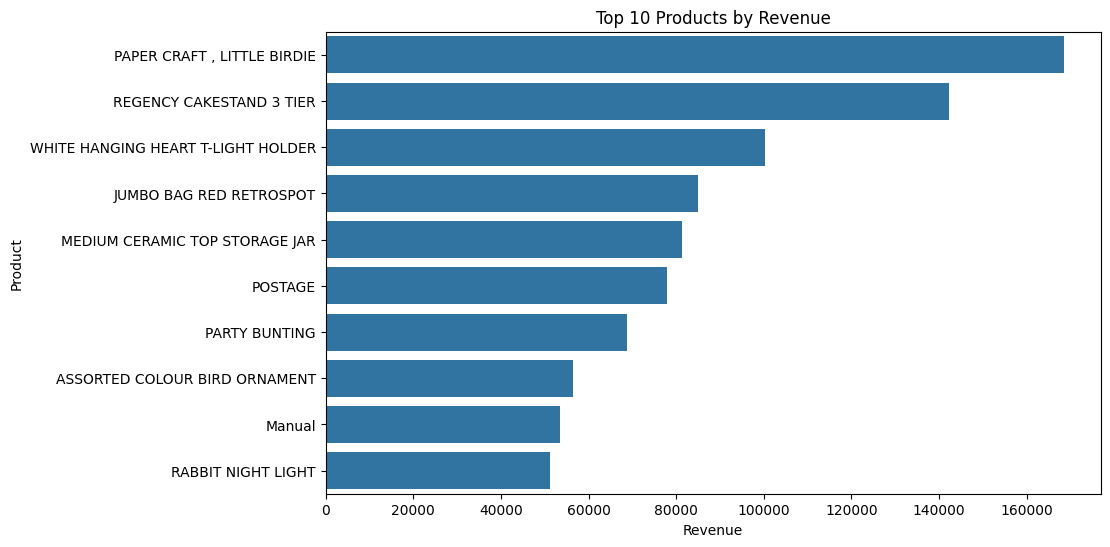

In [79]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=product_revenue.head(10).values,
    y=product_revenue.head(10).index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

Customer Analysis

In [80]:
customer_summary = (
    df_clean.groupby("CustomerID")
    .agg(
        Total_Spend=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_summary.head()

,CustomerID,Total_Spend,Total_Orders,Total_Quantity
0,12346,77183.60,1,74215
1,12347,4310.00,7,2458
2,12348,1797.24,4,2341
3,12349,1757.55,1,631
4,12350,334.40,1,197


Top customers

In [81]:
top_customers = (
    customer_summary
    .sort_values("Total_Spend", ascending=False)
    .head(10)
)

top_customers

,CustomerID,Total_Spend,Total_Orders,Total_Quantity
1689,14646,280206.02,73,196915
4201,18102,259657.30,60,64124
3728,17450,194390.79,46,69973
3008,16446,168472.50,2,80997
1879,14911,143711.17,201,80240
55,12415,124914.53,21,77374
1333,14156,117210.08,55,57768
3771,17511,91062.38,31,64549
2702,16029,80850.84,63,40108
0,12346,77183.60,1,74215


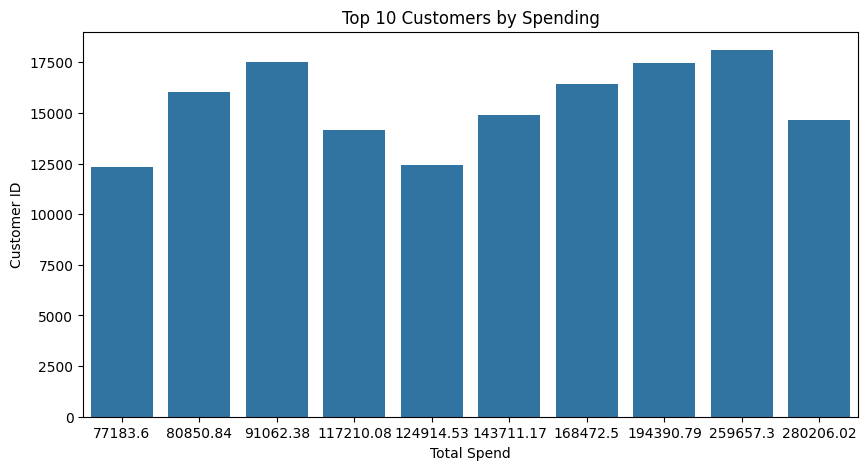

In [82]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_customers,
    x="Total_Spend",
    y="CustomerID"
)

plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spend")
plt.ylabel("Customer ID")

plt.show()

main KPI

In [83]:
total_revenue = df_clean["Revenue"].sum()
total_orders = df_clean["InvoiceNo"].nunique()
total_customers = df_clean["CustomerID"].nunique()

average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 8887208.89
Total Orders: 18532
Total Customers: 4338
Average Order Value: 479.56


Day-wise Sales

In [84]:
day_sales = (
    df_clean.groupby("Day_Name")["Revenue"]
    .sum()
)

day_sales

,Revenue
Day_Name,
Friday,1483080.811
Monday,1363604.401
Sunday,785490.321
Thursday,1973015.730
Tuesday,1697733.801
Wednesday,1584283.830


In [85]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = day_sales.reindex(day_order)

day_sales

,Revenue
Day_Name,
Monday,1363604.401
Tuesday,1697733.801
Wednesday,1584283.830
Thursday,1973015.730
Friday,1483080.811
Saturday,NaN
Sunday,785490.321


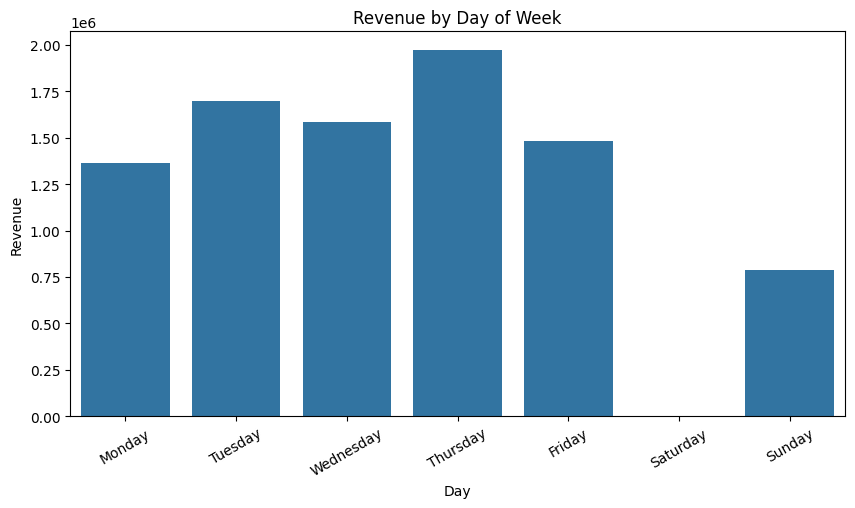

In [86]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.show()

Basic EDA: Quantity & Price

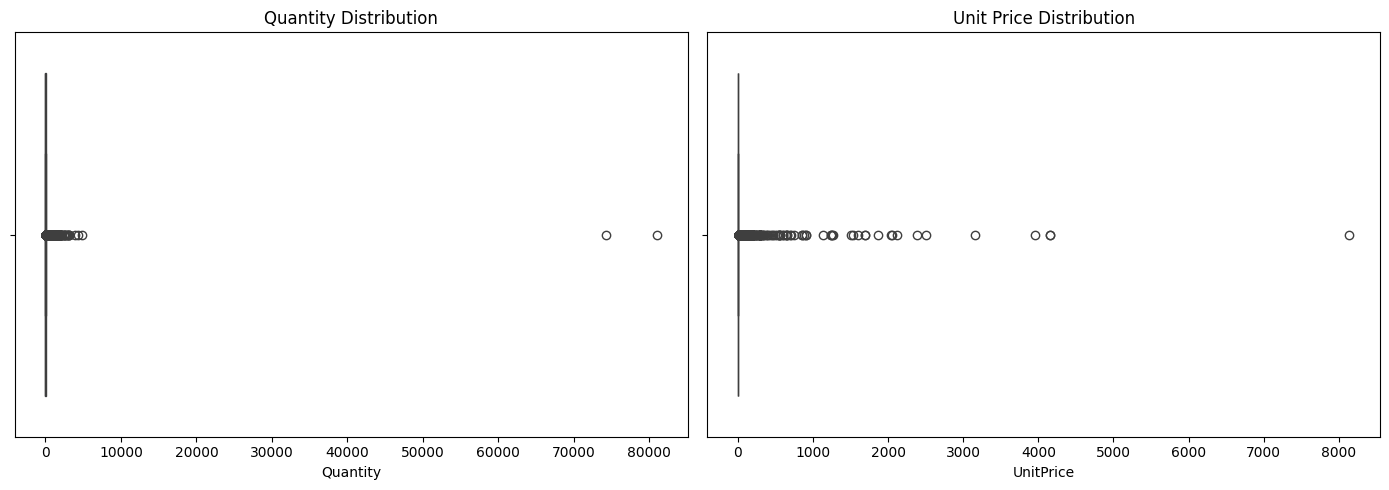

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    x=df_clean["Quantity"],
    ax=axes[0]
)

axes[0].set_title("Quantity Distribution")

sns.boxplot(
    x=df_clean["UnitPrice"],
    ax=axes[1]
)

axes[1].set_title("Unit Price Distribution")

plt.tight_layout()
plt.show()

Final Data Check

In [88]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     392692 non-null  object        
 1   StockCode     392692 non-null  object        
 2   Description   392692 non-null  object        
 3   Quantity      392692 non-null  int64         
 4   InvoiceDate   392692 non-null  datetime64[ns]
 5   UnitPrice     392692 non-null  float64       
 6   CustomerID    392692 non-null  int64         
 7   Country       392692 non-null  object        
 8   Is_Cancelled  392692 non-null  bool          
 9   Revenue       392692 non-null  float64       
 10  Year          392692 non-null  int32         
 11  Month         392692 non-null  int32         
 12  Month_Name    392692 non-null  object        
 13  Day_Name      392692 non-null  object        
 14  Hour          392692 non-null  int32         
dtypes: bool(1), datetime64

In [89]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Is_Cancelled,0
Revenue,0


In [90]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Is_Cancelled,Revenue,Year,Month,Month_Name,Day_Name,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010,12,December,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010,12,December,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00,2010,12,December,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010,12,December,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010,12,December,Wednesday,8


Export cleaned data

In [91]:
df_clean.to_csv(
    "online_retail_clean.csv",
    index=False
)

customer_summary.to_csv(
    "customer_summary.csv",
    index=False
)

print("Files created successfully!")

Files created successfully!


In [92]:
from google.colab import files

files.download("online_retail_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
files.download("customer_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>